# Fit Models

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.base import clone

from tqdm_joblib import tqdm_joblib
from tqdm.auto import tqdm

from bioacoustics.features import augment_temporal_features, augment_sites

from bioacoustics.data import load_results, save_results
from bioacoustics.metrics import evaluate_multilabel_model

from bioacoustics.modeling import FitMode, Classifier, HierarchicalMixtureOfExperts
from bioacoustics.modeling import split_data, get_prediction_pipeline, select_classifier
from bioacoustics.modeling import smooth_proba

from bioacoustics.modeling import get_feature_importance
from bioacoustics.modeling import ignore_warnings

import bioacoustics.visualization as viz

ignore_warnings()  # TODO: fix the reasons for these warnings

%load_ext autoreload
%autoreload 2

/Users/vlad/Documents/University/Master-MIND/bioacoustic-species-detection/.venv/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Problems to think about:

- Multi-label prediction -> hierarchical models? implement with `Pipeline`
- Class imbalance -> tinker with class weights, adjust probabilities?
- Use additional metadata from train, not available in soundscapes
- Maybe use hybrid approaches? learn about how to combine different models' predictions

think about chunking the audio, tuning the threshold for ech class

## Load features and labels

In [2]:
data_train = load_results("features", "data_train")
data_train_soundscapes = load_results("features", "data_train_soundscapes")
data_train_soundscapes_embeddings = load_results("features", "data_train_soundscapes", "embeddings")

# Decided to not keep them as the gain in ROC-AUC is
# marginal (~1%) and they introduce potential recording bias
AUGMENT_WITH_TIME = False
AUGMENT_WITH_SITES = False

if AUGMENT_WITH_TIME:
    data_train_soundscapes["X"] = augment_temporal_features(data_train_soundscapes["X"])
if AUGMENT_WITH_SITES:
    data_train_soundscapes["X"] = augment_sites(data_train_soundscapes["X"])

Note that it doesn't make much sense to validate on iNat or XC data, since it's of different format than test soundscapes.

In [ ]:
FIT_MODE = FitMode.SOUNDSCAPE_TO_SOUNDSCAPE # SOUNDSCAPE_TO_SOUNDSCAPE or MIX_TO_SOUNDSCAPE
USE_EMBEDDINGS = True

if USE_EMBEDDINGS and FIT_MODE != FitMode.SOUNDSCAPE_TO_SOUNDSCAPE:
    print("embeddings were obtained ony for soundscapes")
    USE_EMBEDDINGS = False

X_train_feat, X_test_feat, y_class_train, y_class_test, y_primary_train, y_primary_test = (
    split_data(
        data_train,
        data_train_soundscapes,
        FIT_MODE,
        test_size=0.2,
        random_state=41,
        rare_first=False,
    )
)

if USE_EMBEDDINGS:
    X_train_embed = data_train_soundscapes_embeddings["X"].loc[X_train_feat.index]
    X_test_embed = data_train_soundscapes_embeddings["X"].loc[X_test_feat.index]

About metrics:

The metric they use in BirdClef is macro ROC-AUC a a version of
macro-averaged ROC-AUC that skips classes that have no true positive labels.

- Macro - metric computed per class then averaged, giving each label
equal weight regardless of frequency.

- Micro - metric computed globally by aggregating all true positives,
false positives, and false negatives across labels.

- Hamming loss - fraction of incorrectly predicted label assignments
across all samples and labels.

- LRAP (Label Ranking Average Precision) - evaluates how well true
labels are ranked above others for each sample; averages the rank
quality over true labels and samples.

- Macro metrics are computed only over classes that have at least one
positive sample in the test set; zero-support classes would make
roc_auc_score return NaN and contribute uninformative zeros to F1.

In [4]:
SMOOTH_SIGMA = 4 # 0 if no smoothing

## Baseline species prediction

This is the model we are using for hyperparameter tuning and model selection with cross validation on train data only. 

MoE will use the model selected with cross-validation on the train set.

The validation set defined above is used for final validation and test on more resource-consuming approaches such as MoE.

**On features** we try ensemble models, as they are expected to handle good non-linear feature data: 
- XGBoost
- Random Forest 

**On embeddings** we try linear models, since the `Perch 2.0` was pre-trained so that obtained embeddings are linearly separable.
- Logistic Regression
- SVM

In [ ]:
feature_param_grids = {
    Classifier.XGBOOST: {"clf__estimator__max_depth": [4, 6]},
    Classifier.RF:      {"clf__estimator__max_depth": [10, None]},
}

best_feature_clf, best_feature_params, feature_gs = select_classifier(
    X_train_feat, y_primary_train, feature_param_grids
)

if USE_EMBEDDINGS:
    embedding_param_grids = {
        Classifier.LR:  {"clf__estimator__C": [0.1, 1.0, 10.0]},
        Classifier.SVM: {"clf__estimator__C": [0.1, 1.0, 10.0]},
    }
    best_embed_clf, best_embed_params, embed_gs = select_classifier(
        X_train_embed, y_primary_train, embedding_param_grids
    )


--- XGBOOST ---
Fitting 3 folds for each of 2 candidates, totalling 6 fits
  Best: {'clf__estimator__max_depth': 4}  CV score: 0.7535

--- RF ---
Fitting 3 folds for each of 2 candidates, totalling 6 fits
  Best: {'clf__estimator__max_depth': None}  CV score: 0.7757

=> Best: RF, params: {'max_depth': None}

--- LR ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
  Best: {'clf__estimator__C': 0.1}  CV score: 0.7743

--- SVM ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
  Best: {'clf__estimator__C': 10.0}  CV score: 0.7528

=> Best: LR, params: {'C': 0.1}


In [23]:
CHOOSE_FEATURES = True

assert CHOOSE_FEATURES or USE_EMBEDDINGS, "only features were used"

if CHOOSE_FEATURES:
    CLASSIFIER = best_feature_clf  
    best_params = best_feature_params
    X_train = X_train_feat
    X_test = X_test_feat
else:
    CLASSIFIER = best_embed_clf  
    best_params = best_embed_params
    X_train = X_train_embed
    X_test = X_test_embed

In [10]:
pipeline_baseline = get_prediction_pipeline(CLASSIFIER, **best_params)
with tqdm_joblib(desc="Training OvR", total=y_primary_train.shape[1]):
    pipeline_baseline.fit(X_train, y_primary_train)

Training OvR:   0%|          | 0/234 [00:00<?, ?it/s]

In [11]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(ignore CLASS)".center(60))
eval_report =  evaluate_multilabel_model(pipeline_baseline, X_test, y_primary_test, smooth_sigma=SMOOTH_SIGMA)
save_results(eval_report, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-species_baseline")

        SOUNDSCAPE_TO_SOUNDSCAPE predicting SPECIES         
                       (ignore CLASS)                       
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0360  over 34 classes: 0.2479
Micro F1:     0.5032
Hamming loss: 0.0128

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.8301
Micro ROC AUC: 0.9593
Macro AP:      0.0699  over 34 classes: 0.4809
Micro AP:      0.6016
LRAP:          0.6371


## Taxonomy to predict species

We can use these approaches:

1. **Hierarchical classification:**
    - first predict the class and then train per-class model
    - we must avoid training mismatch - at inference predicted class is used, but at training use only true class, so we better condition on predicted class
    - problems:
        - error propagation if predicted class is wrong
    - **soft version:**
        - $P(s|x) = \sum_c P(s|x,c)P(c|x)$
        - predict class probabilities and use them as soft weights for species classifiers
        - i.e. mixture of experts, soft routing
        - pros:
            - avoids routing errors
            - more consistent as a probability model
    - ideas:
        - I'm afraid class signal will be hidden by hundreds of features, maybe we should emphasize it?
    - multilabel problem:
        - since data is multilabel, classes are not mutually exclusive, it means that when we do an averages sum of preicted probabilities, it will not sum to 1
        - so we would need to normalize it or just do average prediction across experts

1. **Feature augmentation**
    - include predicted class as a new feature:
    - no hard routing, so more robust
    - simple to implement
    - problems:
        - this feature can be noisy
    - **soft version:**
        - include predicted class probabilities as new features

1. Other ideas:
    - hierarchical loss (penalize wrong species but good class less)

We would focus on soft approaches as they are more robust since they avoid noisy hard class assignment.

### Predict class



In [12]:
pipeline_class = get_prediction_pipeline(CLASSIFIER)
with tqdm_joblib(desc="Training OvR", total=y_class_train.shape[1]):
    pipeline_class.fit(X_train, y_class_train)

Training OvR:   0%|          | 0/5 [00:00<?, ?it/s]

In [13]:
print(f"{FIT_MODE.name} predicting CLASS".center(60))
eval_report = evaluate_multilabel_model(pipeline_class, X_test, y_class_test)
save_results(eval_report, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-class")

         SOUNDSCAPE_TO_SOUNDSCAPE predicting CLASS          

================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

    Amphibia       0.98      1.00      0.99       116
        Aves       0.75      0.68      0.71        56
     Insecta       1.00      0.97      0.99        36
    Mammalia       1.00      0.50      0.67         2
    Reptilia       0.00      0.00      0.00         4

   micro avg       0.93      0.89      0.91       214
   macro avg       0.75      0.63      0.67       214
weighted avg       0.91      0.89      0.90       214
 samples avg       0.94      0.93      0.92       214


================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.6709
Micro F1:     0.9069
Hamming loss: 0.0503

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: 0.9771666270398522
Micro ROC AUC: 0.9820
Macro AP:      0.9726
Micro AP:      0.9729
LRAP:          0.9782


In [14]:
N_FOLDS = 5

# use out-of-fold (OOF) prediction unbiased class probabilities for training samples
y_class_train_proba = cross_val_predict(
    clone(pipeline_class), X_train, y_class_train,
    cv=KFold(n_splits=N_FOLDS, shuffle=True, random_state=42),
    method="predict_proba",
)
y_class_test_proba = pipeline_class.predict_proba(X_test)

### Soft hierarchical classification

In [15]:
expert_pipelines = HierarchicalMixtureOfExperts(y_class_test.shape[1], CLASSIFIER)
expert_pipelines.fit(X_train, y_class_train, y_primary_train)

Training expert for Amphibia  :   0%|          | 0/38 [00:00<?, ?it/s]

Training expert for Aves      :   0%|          | 0/54 [00:00<?, ?it/s]

Training expert for Insecta   :   0%|          | 0/47 [00:00<?, ?it/s]

Training expert for Mammalia  :   0%|          | 0/23 [00:00<?, ?it/s]

Training expert for Reptilia  :   0%|          | 0/22 [00:00<?, ?it/s]

In [16]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(soft mixture of CLASS experts)".center(60))
eval_report = evaluate_multilabel_model(expert_pipelines, X_test, y_primary_test, y_class_test_proba, smooth_sigma=SMOOTH_SIGMA)
save_results(eval_report, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-species_moe")

        SOUNDSCAPE_TO_SOUNDSCAPE predicting SPECIES         
              (soft mixture of CLASS experts)               
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0398  over 34 classes: 0.2736
Micro F1:     0.5342
Hamming loss: 0.0122

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.8326
Micro ROC AUC: 0.9566
Macro AP:      0.0702  over 34 classes: 0.4833
Micro AP:      0.6021
LRAP:          0.6297


### Soft feature augmentation

In [17]:
X_test_augmented = np.concatenate([X_test, y_class_test_proba], axis=1)
X_train_augmented = np.concatenate([X_train, y_class_train_proba], axis=1)

pipeline_augmentation = get_prediction_pipeline(CLASSIFIER)

with tqdm_joblib(desc="Training OvR", total=y_primary_train.shape[1]):
    pipeline_augmentation.fit(X_train_augmented, y_primary_train)

Training OvR:   0%|          | 0/234 [00:00<?, ?it/s]

In [18]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(CLASS feature augmentation)".center(60))
eval_report = evaluate_multilabel_model(pipeline_augmentation, X_test_augmented, y_primary_test)
save_results(eval_report, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-species_feat_augmentation")

        SOUNDSCAPE_TO_SOUNDSCAPE predicting SPECIES         
                (CLASS feature augmentation)                
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0346  over 34 classes: 0.2381
Micro F1:     0.5027
Hamming loss: 0.0129

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.8184
Micro ROC AUC: 0.9505
Macro AP:      0.0689  over 34 classes: 0.4740
Micro AP:      0.5697
LRAP:          0.6238


## Interpret the model

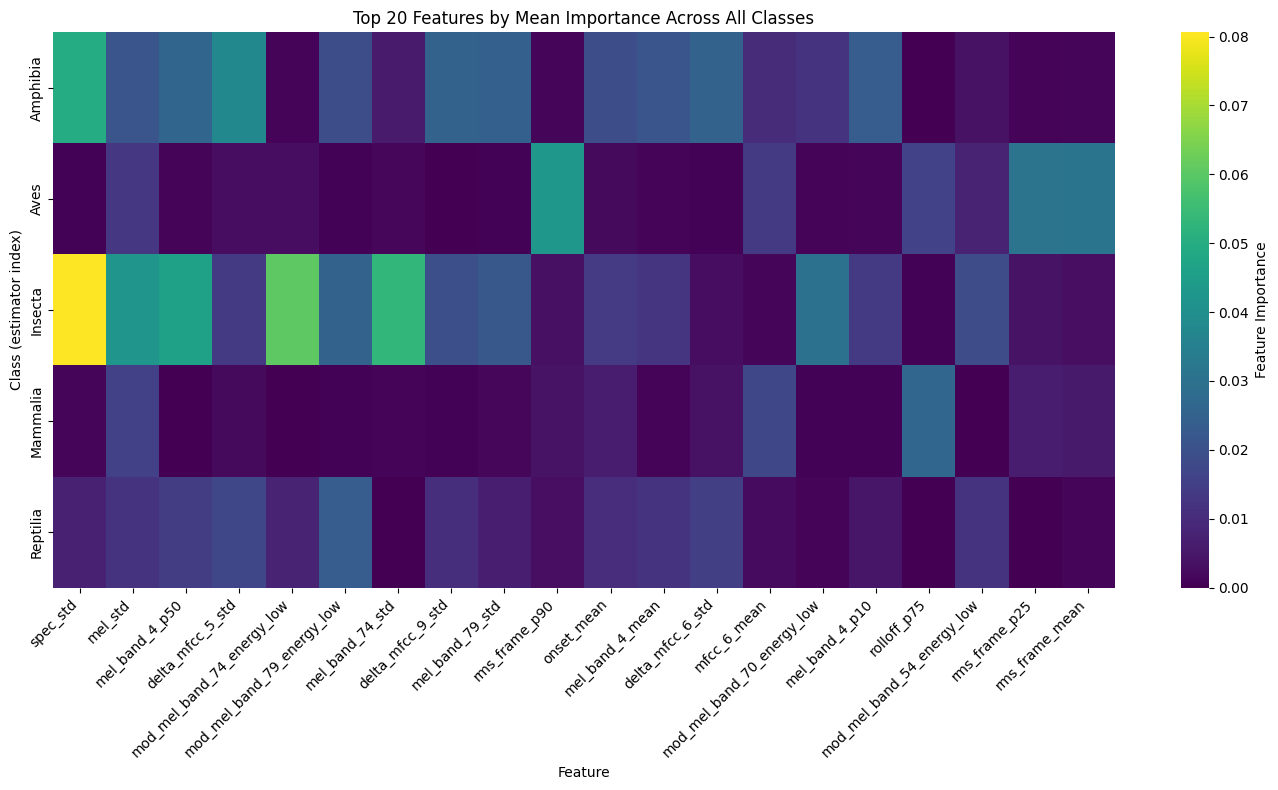

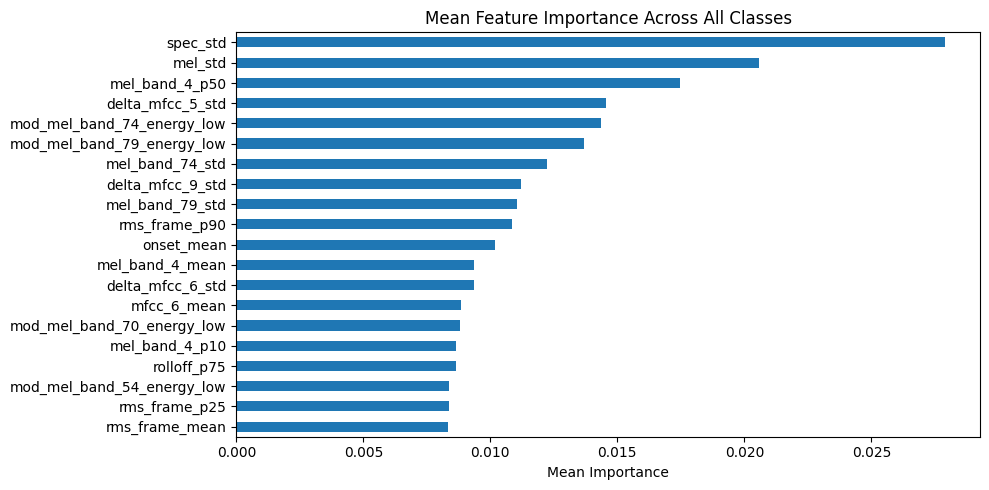

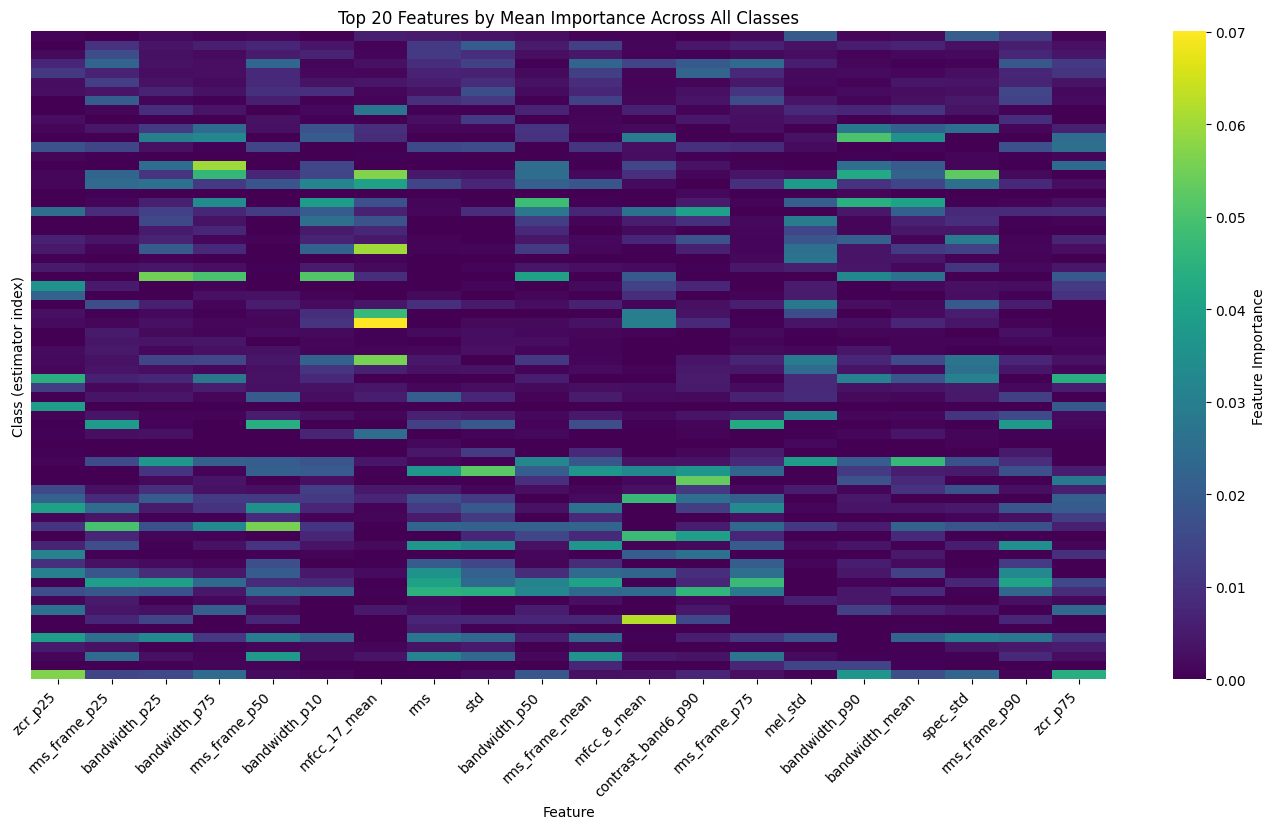

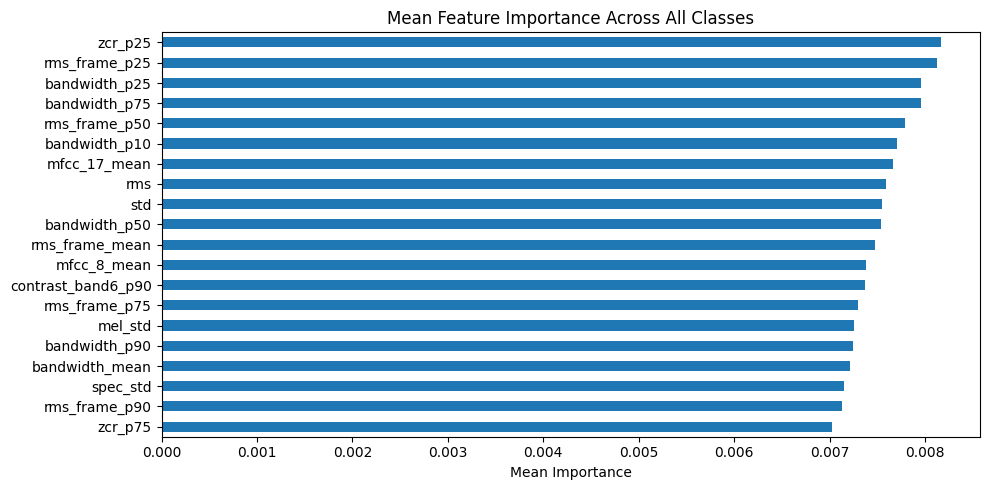

In [19]:
for pipeline in (pipeline_class, pipeline_baseline):
    class_names = y_class_train.columns
    primary_names = y_primary_train.columns
    df_importance = get_feature_importance(pipeline, class_names)
    TOP_N = 20
    viz.plot_importance_heatmap(df_importance, top_n=TOP_N)
    viz.plot_importance_mean(df_importance, top_n=TOP_N)

## Closer inspection of errors

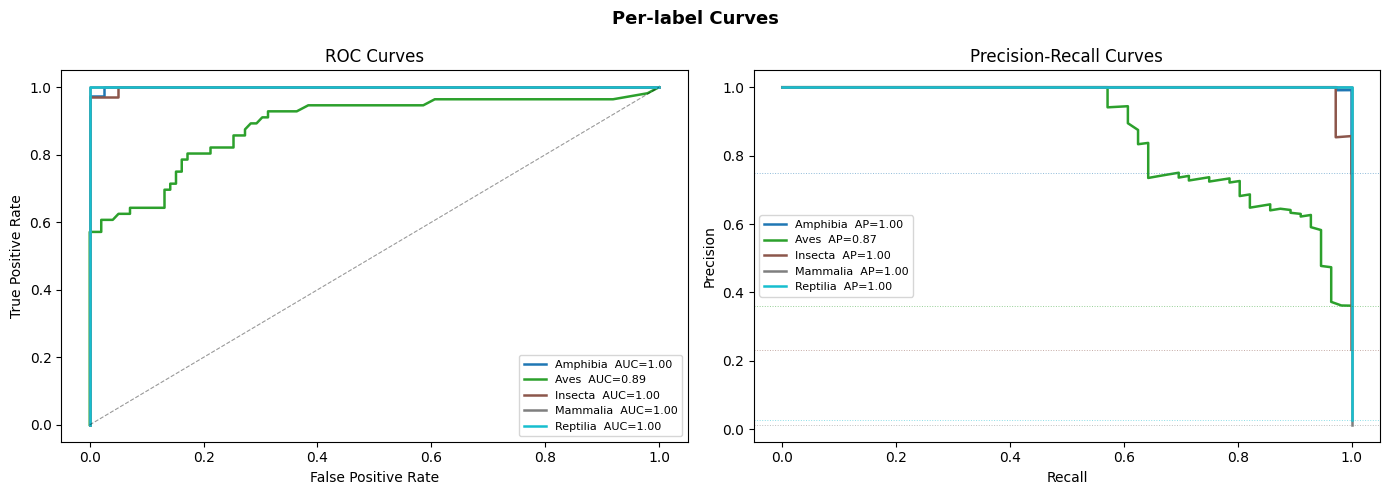

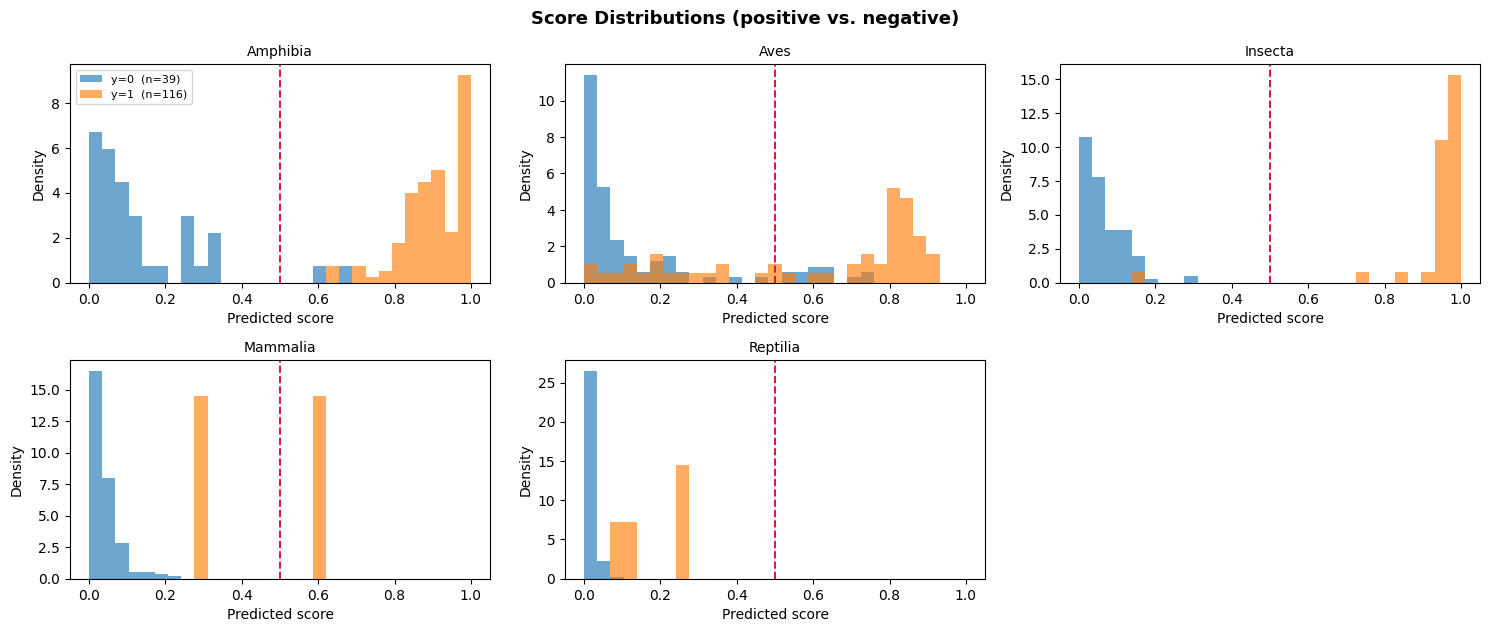

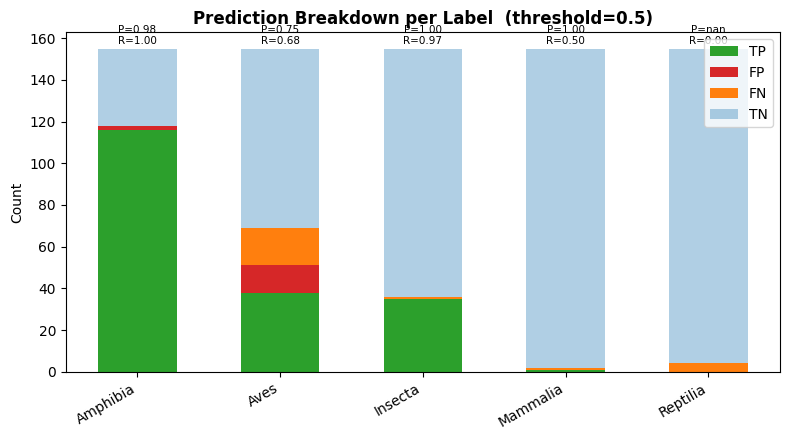

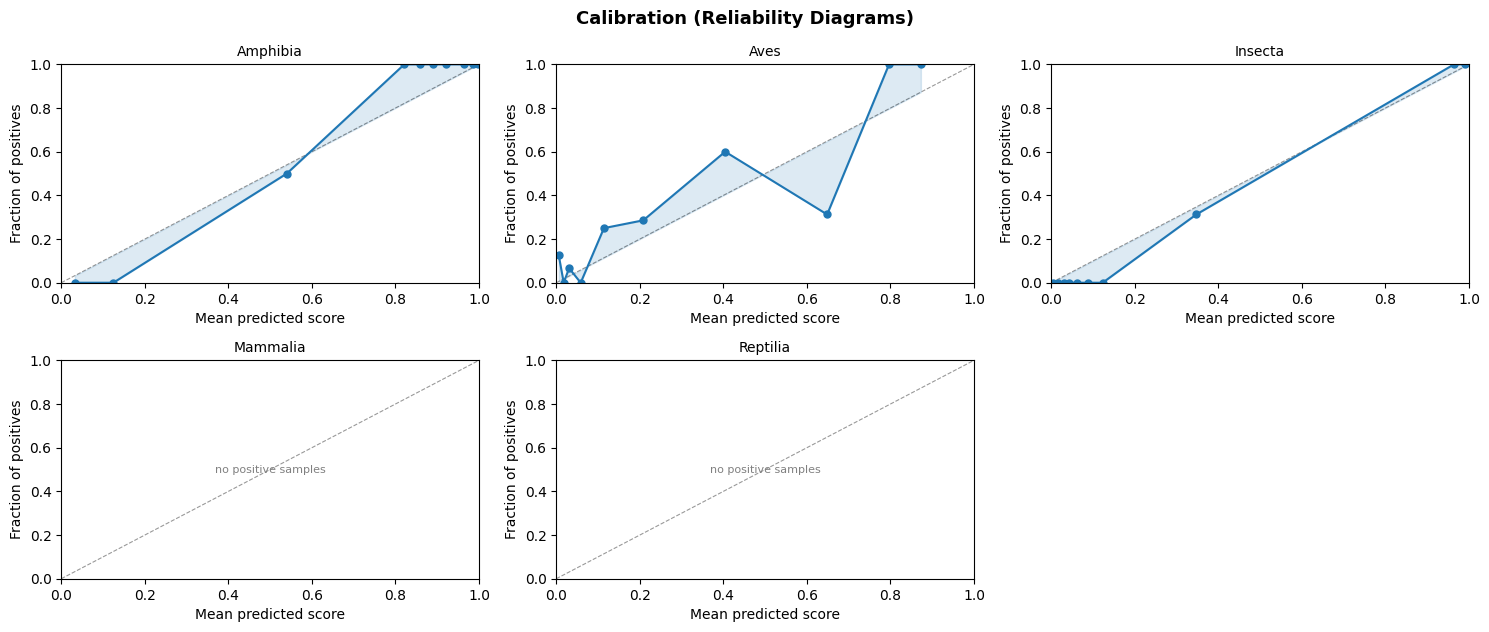

In [20]:
y_proba = pipeline_class.predict_proba(X_test)
viz.plot_multilabel_errors(y_class_test, y_proba, threshold=0.5)

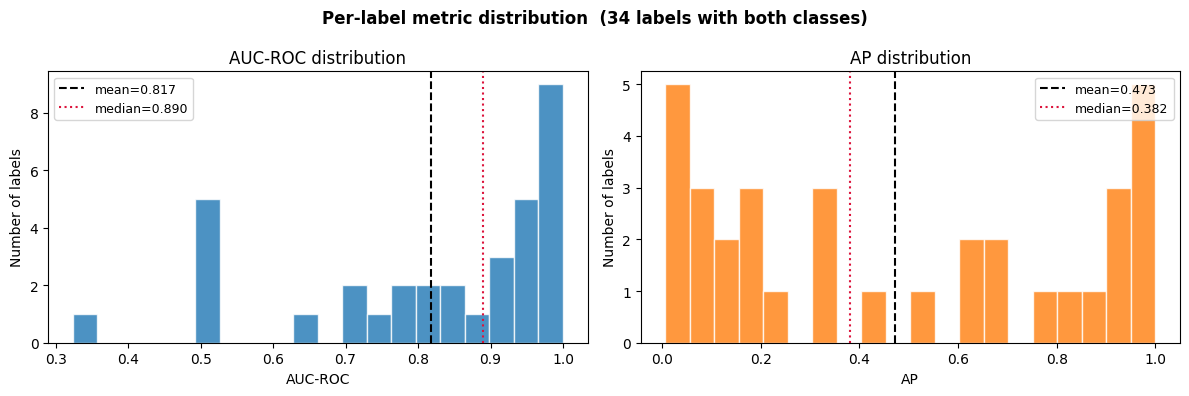

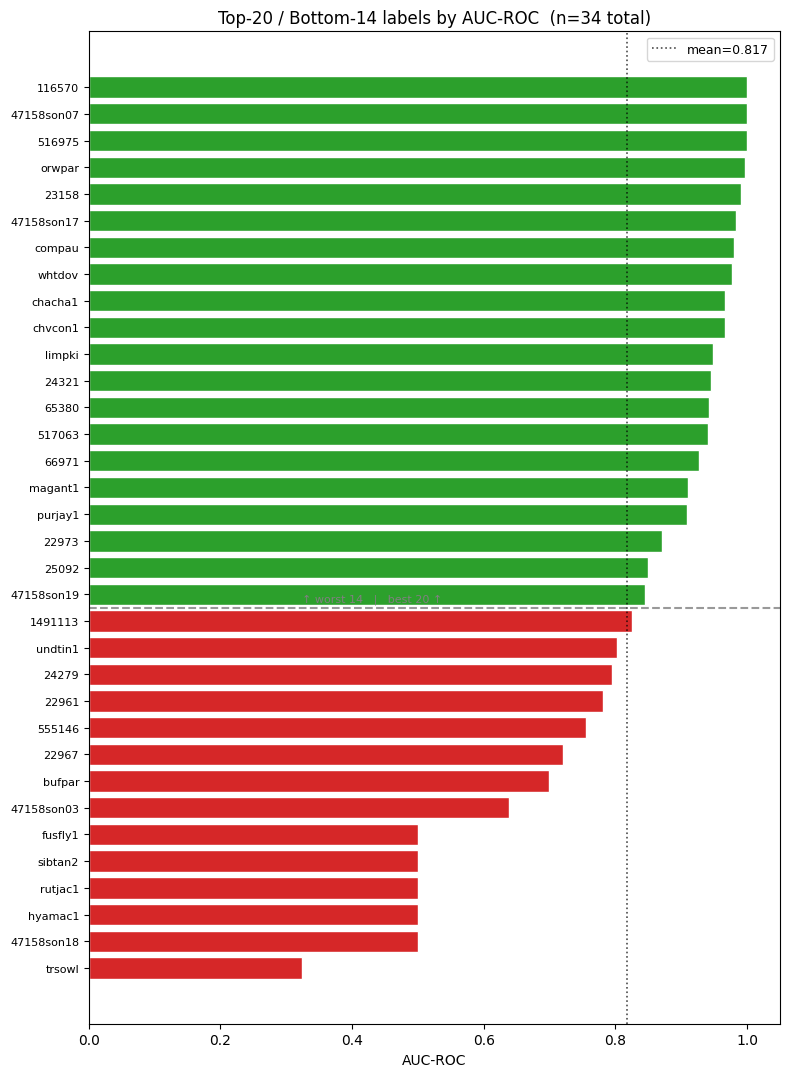

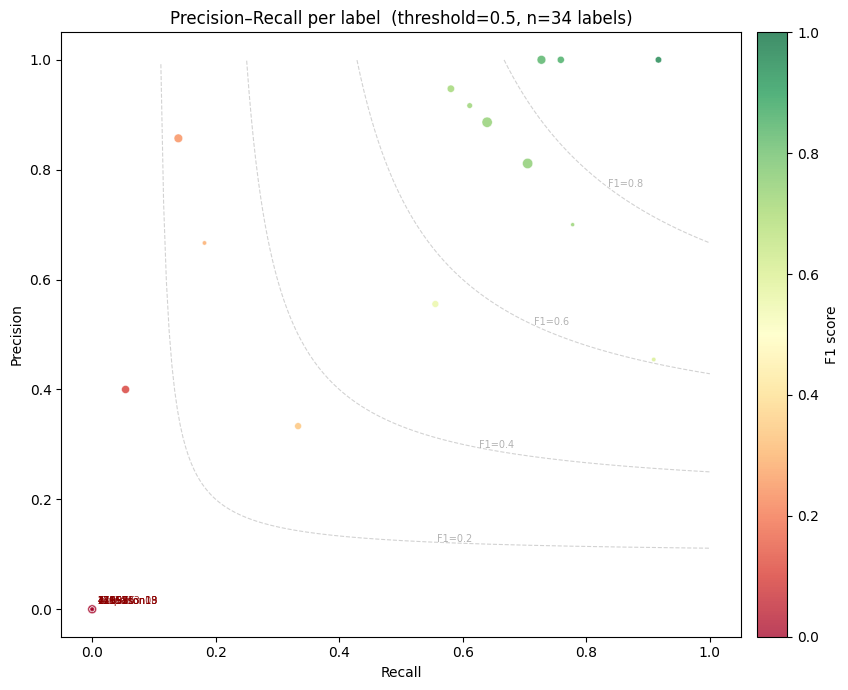

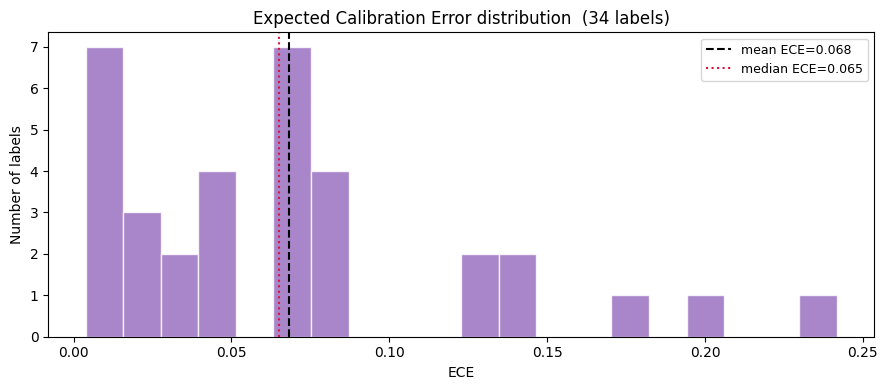

In [21]:
y_proba = pipeline_baseline.predict_proba(X_test)
viz.plot_multilabel_errors_large(y_primary_test, y_proba, threshold=0.5)

# SANDBOX

In [22]:
# TODO: the same idea for training metadata that is absent for the test
# - we can learn to predict this metadata as a secondary task and then include
# it in the model

# NOTE: attention to data leak between train - validation when using secondary tasks
# to generate features (class, metadata)

# TODO: can use this metadata as well for stratification - better split validation
# (make sure that there is no data leak because of the same site)
# TODO: check whether metadata alone can predict species (check for shortcut learning)

# TODO: smart cross validations

# TODO: quality of train audio from iNat and xeno-cant is poorer and further from test than train soundscapes,
#       so maybe we should use them only for species poorly covered by soundscapes

# TODO: impute some NaNs

# TODO: maybe stratify be species or sth else since train data had
#   too (really) many bird recordings, whereas soundscapes contain more amphibians

# TODO: maybe play with thresholds

# TODO: temporal smoothing of predicted probabilities!